Max Energy Target : 150 MeV
SOBP Range        : 9.77 cm to 13.15 cm


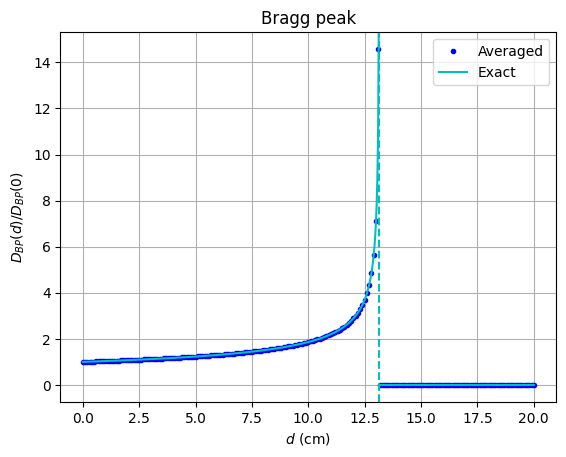

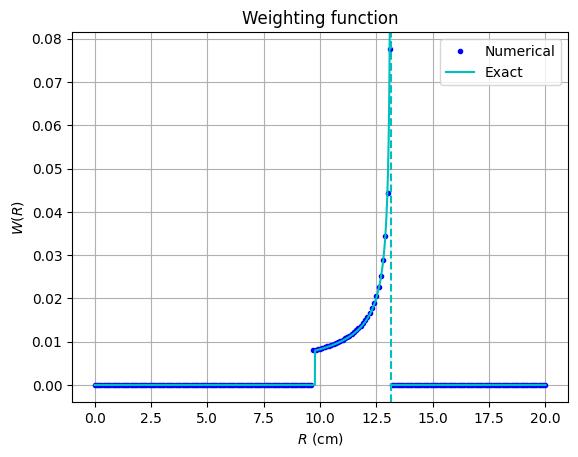

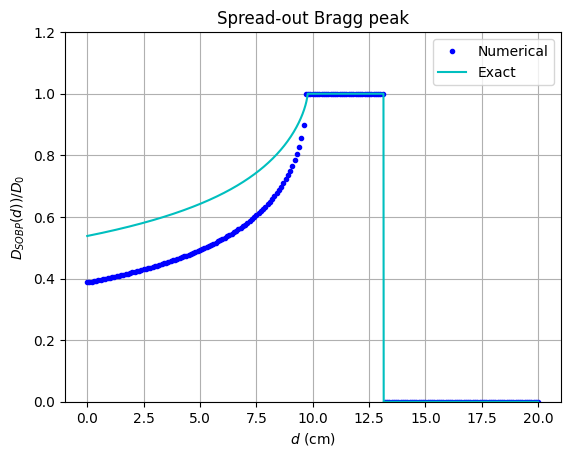


 EXTRACTION RESULTS OF 35 BORTFELD BEAMS FOR TOPAS SIMULATION
150.000000
149.044962
148.396135
147.745115
147.091879
146.436402
145.778657
145.118620
144.456263
143.791559
143.124480
142.454999
141.783086
141.108713
140.431848
139.752463
139.070524
138.386001
137.698861
137.009070
136.316595
135.621400
134.923451
134.222710
133.519141
132.812706
132.103365
131.391080
130.675808
129.957510
129.236141
128.511658
127.784016
127.053170
126.319073



In [1]:
import numpy as np
from scipy import signal, integrate
import matplotlib.pyplot as plt

# =========================================================
# 1. DYNAMIC ENERGY AND TARGET PARAMETER SETTINGS
# =========================================================
E_max = 150       # Maximum projectile energy (in MeV) 
sobp_width = 3.375 # 25% SOBP plateau width (in cm) from R0 at Pristine 150 MeV PMMA

# Medium Physics Parameters (PMMA)
alpha = 0.00185     # Empirical constant
p = 1.77            # Empirical exponent
D0 = 1.0            # SOBP target dose (Relative)

# =========================================================
# AUTOMATIC CONVERSION: Energy -> Depth (Z Axis)
# =========================================================
# Bortfeld range-energy formula: R = alpha * E^p
db = alpha * (E_max ** p)     # Depth of the deepest stopping proton (Distal Edge)
da = db - sobp_width          # Initial depth of the tumor (Proximal Edge)

print(f"Max Energy Target : {E_max} MeV")
print(f"SOBP Range        : {da:.2f} cm to {db:.2f} cm")

# Shorthand for oft-used expressions
a = alpha**(1.0/p)
q = 1.0 - 1.0/p

# Stopping power S = -dE/dd, mirrored about the y-axis and shifted by db (Bortfeld & Schlegel (1996), Eq. (A5))
def g(d):
    return np.piecewise(d,[d<0,d>0],[0,lambda d: 1.0/(p*a*d**q)])

def Bragg_peak(R,d):
    return g(R-d)

# Numerically computes the average of a function "func" on the interval [d0,d1]
def average(func,d0,d1):
    integral,_ = integrate.quad(func,d0,d1)/(d1-d0)
    return integral

# For a function defined for x>0, given an array x of grid values, returns an array of average
# function values on intervals [x[n]-dx/2, x[n]+dx/2], where x[n] is a grid value and dx the grid spacing
def impulse(func,x):
    h = np.zeros(len(x))
    dx = x[1] - x[0]
    h[0] = average(func, 0, 0.5*dx)
    for n in range(1,N):
        h[n] = average(func, x[n]-0.5*dx, x[n]+0.5*dx)
    return h

def W(R):
    return np.piecewise(R,[(da<=R) & (R<db)],[lambda R: D0*p*np.sin(np.pi/p)*a/(np.pi*(db-R)**(1.0/p)), 0])

# Performs the reverse of the transforms defined in Eq. (A3) of Bortfeld & Schlegel (1996)
def back_transform(w,da,db,x):
    N = len(x)
    dx = x[1] - x[0]
    Na = int(da/dx)
    Nb = int(db/dx)
    w = w[:Nb+1]
    w_reverse = w[::-1]
    return np.concatenate((np.zeros(Na), w_reverse[Na:Nb+1], np.zeros(N-Nb-1)))

# Part of the exact solution of the spread-out Bragg peak for p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_buildup(d,da,db,D0):
    r = (da - d)/(db - da)
    r_hat = r**(1.0/3.0)
    return D0*(0.75+np.sqrt(3)/(4*np.pi)*np.log((1+r_hat)**2/(1-r_hat+r_hat**2))-3.0/(2.0*np.pi)*np.arctan((2*r_hat-1)/np.sqrt(3)))

# Full piecewise-defined analytical solution for the SOBP with p = 1.5 (Bortfeld & Schlegel (1996), Eq. (6))
def SOBP_analytic(d,da,db,D0):
    return np.piecewise(d,[(0<=d) & (d<da),(da<=d) & (d<=db)],[lambda d: SOBP_buildup(d,da,db,D0), D0, 0])

# Add grid and legend to plots
def add_grid_legend():
    plt.grid('on')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, loc = 'best')

# Definition of the depth grid
N = 201                         # Number of grid points
dmax = 20.0                     # Maximum depth up to which to generate model output
d = np.linspace(0,dmax,N)       # Depth grid
dd = d[1] - d[0]                # Depth grid spacing
Na = int(da/dd)                 # Grid point index corresponding to d = da
Nb = int(db/dd)                 # Grid point index corresponding to d = db

g_avs = impulse(g,d)            # Impulse response function (with averaging applied to remove singularity)

M = N                           # Length of inverse filter response w(R)
d_w = np.arange(M)*dd           # Depth grid for w(R)
Nd = M + N - 1                  # Number of output samples needed to obtain the inverse filter response of the required length

yd = D0*np.ones(Nd)             # Heaviside step function of length Nd

# Perform deconvolution of the step function with the averaged impulse response
w, remainder = signal.deconvolve(yd,g_avs)
w /= dd                        # Divide by grid spacing to obtain an approximation of the continuous-valued weighting function

w2 = back_transform(w,da,db,d)

# Obtain the spread-out Bragg peak by deconvolution (cf. Bortfeld & Schlegel (1996), Eq. (B1))
SOBP = dd * signal.convolve(w2,g_avs[::-1])
SOBP = SOBP[N-1:]               # Remove boundary effects at the beginning of the convolution output

# Figure 1: Illustration of the Bragg peak
plt.figure(1)
Ncont = 2001                        # More finely spaced, 'continuous' grid for plotting exact solution
dcont = np.linspace(0,dmax,Ncont)
dx_cont = dcont[1] - dcont[0]

gx = Bragg_peak(db,dcont)           # Exact Bragg peak (Bortfeld & Schlegel, Eq. (3))
gx /= gx[0]                         # Normalize by value at d = 0
gx[int(db/dx_cont)] = np.nan                 # Set to not-a-number at the singularity at d = db

gn = impulse(lambda d: Bragg_peak(db,d),d)      # Discretized Bragg peak in which the singularity at d = db is removed by averaging
gn /= gn[0]                                     # Normalized by value at d = 0

plt.plot(d,gn,'b.',label='Averaged')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits for the discrete (averaged) Bragg peak only
plt.plot(dcont,gx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.title("Bragg peak")
plt.xlabel('$d$ (cm)')
plt.ylabel(r'$D_{BP}\left( d \right)/D_{BP}\left( 0 \right)$')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 2: Weighting function
plt.figure(2)
wx = W(dcont)           # Exact weighting function (Bortfeld & Schlegel (1996), Eq. (4))
wx[int(db/dx_cont)] = np.nan
plt.plot(d,w2,'b.',label='Numerical')
ymin,ymax = plt.gca().get_ylim()                # Record auto-scaled axis limits
plt.plot(dcont,wx,'c',label='Exact')
plt.axvline(x=db,color='c',linestyle='--')
plt.xlabel('$R$ (cm)')
plt.ylabel(r'$W\left(R\right)$')
plt.title('Weighting function')
plt.gca().set_ylim(ymin,ymax)
add_grid_legend()

# Figure 3: Spread-out Bragg peak
plt.figure(3)
plt.plot(d,SOBP,'b.',label='Numerical')
plt.plot(dcont,SOBP_analytic(dcont,da,db,D0),'c',label='Exact')
plt.xlabel('$d$ (cm)')
plt.ylabel('$D_{SOBP}(d))/D_0$')
plt.title('Spread-out Bragg peak')
plt.ylim([0,1.2*D0])
add_grid_legend()

plt.show()

# ---------------------------------------------------------
# ADDITIONAL CODE FOR DATA EXTRACTION TO TOPAS
# ---------------------------------------------------------
# 1. Extract Range (cm) and raw weights from the SOBP target area
# Add .copy() so the original array doesn't change when we modify its elements
beam_ranges = d[Na:Nb+1].copy()
beam_weights_raw = w2[Na:Nb+1]

# MAIN CHANGE: Force the last range value to be exactly equal to the exact db
beam_ranges[-1] = db 

# 2. Convert Range (cm) to Energy (MeV)
# Since the last element is now the exact db, the reverse calculation will yield exactly E_max
beam_energies = (beam_ranges / alpha) ** (1.0 / p)

# 3. Normalize weights to TOPAS particle count scale (Maximum 100,000 particles)
max_weight = np.max(beam_weights_raw)
# ... (Rest of the code remains the same)

# 4. Display results from HIGHEST Energy (Deepest) to LOWEST
print(f"\n{'='*68}")
print(f" EXTRACTION RESULTS OF {len(beam_ranges)} BORTFELD BEAMS FOR TOPAS SIMULATION")
print(f"{'='*68}")

# Loop backwards so the output sequence starts from the deepest penetration energy (15 cm) 
# which is required for the PRISTINE.txt file
for i in range(len(beam_ranges) - 1, -1, -1):
    energy_mev = beam_energies[i]
    range_cm = beam_ranges[i]
    sequence = len(beam_ranges) - i
    
    print(f"{energy_mev:6.6f}")
print(f"{'='*68}\n")